In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving salary.csv to salary.csv


 Dataset Loaded Successfully!

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
Missing Values Before Cleaning:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64
 Missing Values After Cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
 Model Evaluation:
R² Score: 0.898
Mean Abso

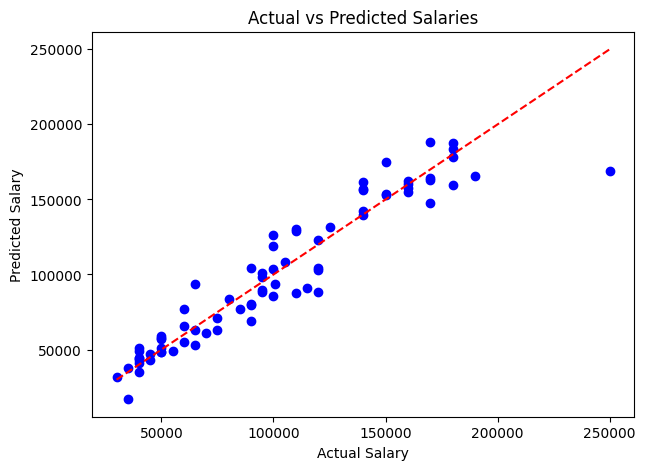

Feature Importance (Model Coefficients):
               Feature   Coefficient
0                  Age   3422.725697
1       Gender_encoded   7552.473974
2    Education_encoded  14963.340557
3          Job_encoded     39.133694
4  Years of Experience   2205.210203
Predicted Salary for Male, Bachelor's, Software Engineer, 5 years experience, age 30: ₹62,184.68
Predicted Salary for Female, Master's, Data Analyst, 3 years experience, age 28: ₹52,782.69
Predicted Salary for Male, PhD, Senior Manager, 15 years experience, age 40: ₹147,255.84


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
data = pd.read_csv("/content/salary.csv")
print(" Dataset Loaded Successfully!\n")
print(data.head())


print("Missing Values Before Cleaning:")
print(data.isnull().sum())


num_cols = ['Age', 'Years of Experience', 'Salary']
for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())


cat_cols = ['Gender', 'Education Level', 'Job Title']
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
print(" Missing Values After Cleaning:")
print(data.isnull().sum())
le_gender = LabelEncoder()
le_edu = LabelEncoder()
le_job = LabelEncoder()

data['Gender_encoded'] = le_gender.fit_transform(data['Gender'])
data['Education_encoded'] = le_edu.fit_transform(data['Education Level'])
data['Job_encoded'] = le_job.fit_transform(data['Job Title'])
X = data[['Age', 'Gender_encoded', 'Education_encoded', 'Job_encoded', 'Years of Experience']]
y = data['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(" Model Evaluation:")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 2))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Salaries")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("Feature Importance (Model Coefficients):")
print(coef_df)
def predict_salary(age, gender, edu, job, exp):
    gender_encoded = le_gender.transform([gender])[0]
    edu_encoded = le_edu.transform([edu])[0]
    job_encoded = le_job.transform([job])[0]
    prediction = model.predict([[age, gender_encoded, edu_encoded, job_encoded, exp]])[0]
    print(f"Predicted Salary for {gender}, {edu}, {job}, {exp} years experience, age {age}: ₹{prediction:,.2f}")
predict_salary(30, "Male", "Bachelor's", "Software Engineer", 5)
predict_salary(28, "Female", "Master's", "Data Analyst", 3)
predict_salary(40, "Male", "PhD", "Senior Manager", 15)
